# 01 数据探查：样本量、字段、时间分布与缺失情况

第一阶段探索性分析。数据来自 GitHub 公开仓库 [xucoolboy/Data_job_in_lagou](https://github.com/xucoolboy/Data_job_in_lagou)（下载脚本见 `src/download_data.py`）：

- `position_sql.csv`：2017 年年中拉勾网**全国数据相关岗位**职位表
- `company_sql.csv`：与职位表配套的公司表
- `lagou_hz_2.csv`：2018-05-17 采集的拉勾网**杭州站数据分析岗位**表（含完整职位描述文本）

In [1]:
# -*- coding: utf-8 -*-
from pathlib import Path
import datetime as dt
import re

import matplotlib.pyplot as plt
import pandas as pd

# Windows 系统中文字体，保证图表中文正常显示
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

RAW = Path("../data/raw/lagou_2017")
FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

pos = pd.read_csv(RAW / "position_sql.csv")                      # 2017 年全国职位表
com = pd.read_csv(RAW / "company_sql.csv")                      # 2017 年公司表
hz = pd.read_csv(RAW / "lagou_hz_2.csv", encoding="utf-8-sig")  # 2018-05 杭州站岗位表

for name, df in {"position_sql": pos, "company_sql": com, "lagou_hz_2": hz}.items():
    print(f"{name}: {df.shape[0]} 行 x {df.shape[1]} 列")

position_sql: 5031 行 x 12 列
company_sql: 2296 行 x 6 列
lagou_hz_2: 431 行 x 21 列


## 1. 样本量、字段与缺失情况

In [2]:
def 表概况(df: pd.DataFrame) -> pd.DataFrame:
    """输出每列的类型、缺失数、缺失率与唯一值数。"""
    return pd.DataFrame({
        "类型": df.dtypes.astype(str),
        "缺失数": df.isna().sum(),
        "缺失率%": (df.isna().mean() * 100).round(1),
        "唯一值数": df.nunique(),
    })

print("【position_sql：2017 全国职位表】")
display(表概况(pos))
print("【company_sql：2017 公司表】")
display(表概况(com))
print("【lagou_hz_2：2018-05 杭州站岗位表】")
display(表概况(hz))

【position_sql：2017 全国职位表】


,类型,缺失数,缺失率%,唯一值数
positionId,int64,0,0.0,5031
city,str,0,0.0,13
companyId,int64,0,0.0,2296
firstType,str,4,0.1,15
secondType,str,3,0.1,56
education,str,0,0.0,5
industryField,str,0,0.0,175
positionAdvantage,str,0,0.0,4201
positionName,str,0,0.0,2165
positionLables,str,24,0.5,1048


【company_sql：2017 公司表】


,类型,缺失数,缺失率%,唯一值数
companyId,int64,0,0.0,2296
companyFullName,str,0,0.0,2262
companyLabelList,str,364,15.9,1297
companyShortName,str,0,0.0,2243
companySize,str,0,0.0,6
businessZones,str,655,28.5,927


【lagou_hz_2：2018-05 杭州站岗位表】


,类型,缺失数,缺失率%,唯一值数
web-scraper-order,str,0,0.0,431
web-scraper-start-url,str,0,0.0,1
link,str,0,0.0,336
link-href,str,0,0.0,431
department,str,2,0.5,349
job_title,str,2,0.5,200
salary,str,2,0.5,85
work_place,str,2,0.5,1
work_year,str,2,0.5,6
education,str,2,0.5,4


## 2. 时间范围

- 2017 年全国职位表**不含发布时间字段**，只能定位为 2017 年年中的横截面快照（来源说明见 `data/raw/lagou_2017/README_数据来源说明.md`）。
- 杭州站表的 `publish_time` 为混合格式：当天发布显示 `HH:MM`，近期显示 `N天前`，更早显示 `YYYY-MM-DD`。采集时刻可从 `web-scraper-order` 内嵌的 Unix 时间戳恢复，据此把发布时间统一换算为日期。

In [3]:
# 从 web-scraper-order 内嵌时间戳恢复采集日期（2018-05-17）
采集时刻 = pd.to_datetime(hz["web-scraper-order"].str.split("-").str[0].astype("int64"), unit="s")
采集日期 = 采集时刻.max().normalize()
print("采集日期:", 采集日期.date())

def 解析发布时间(文本) -> pd.Timestamp | None:
    """把拉勾网的相对/绝对发布时间统一换算为日期。"""
    if pd.isna(文本):
        return None
    文本 = str(文本).replace("\xa0", " ").strip()
    m = re.match(r"^(\d{4}-\d{2}-\d{2})", 文本)
    if m:  # 绝对日期
        return pd.Timestamp(m.group(1))
    m = re.match(r"^(\d+)天前", 文本)
    if m:  # 相对天数
        return 采集日期 - dt.timedelta(days=int(m.group(1)))
    if re.match(r"^\d{2}:\d{2}", 文本):  # 当天发布只显示时刻
        return 采集日期
    return None

hz["发布日期"] = hz["publish_time"].map(解析发布时间)
print("可解析比例:", round(hz["发布日期"].notna().mean(), 3))
print(hz["发布日期"].value_counts().sort_index())

采集日期: 2018-05-17
可解析比例: 0.995
发布日期
2018-04-17      2
2018-04-18      3
2018-04-23      3
2018-04-24      1
2018-04-25      3
2018-04-26      1
2018-04-27      5
2018-04-28      3
2018-05-02     14
2018-05-03      3
2018-05-04      3
2018-05-07     17
2018-05-08      6
2018-05-09      9
2018-05-10     10
2018-05-11     10
2018-05-12      2
2018-05-13      2
2018-05-14     43
2018-05-15     38
2018-05-16     73
2018-05-17    178
Name: count, dtype: int64


## 3. 岗位基本分布（城市 / 学历 / 工作经验）

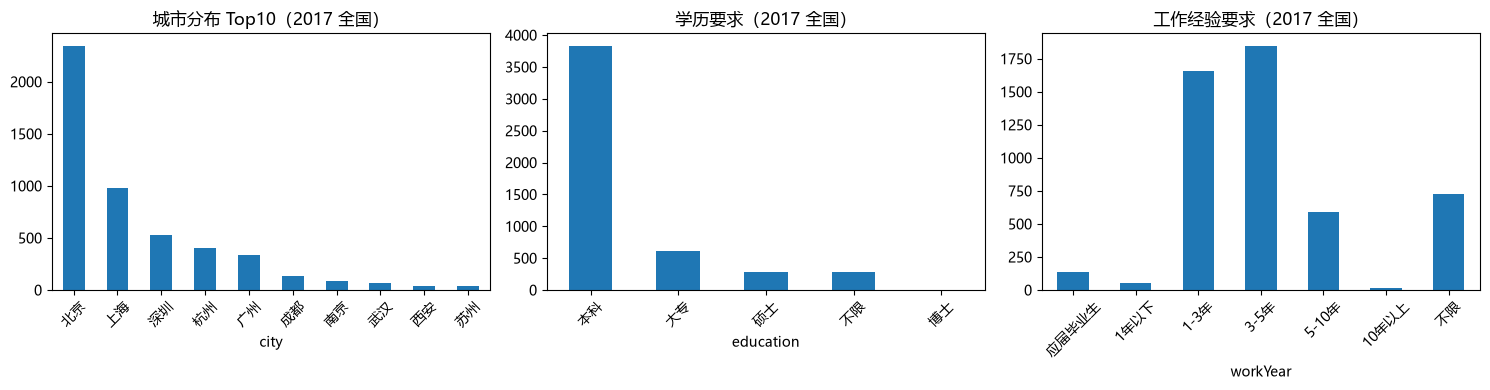

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pos["city"].value_counts().head(10).plot.bar(ax=axes[0], title="城市分布 Top10（2017 全国）")
pos["education"].value_counts().plot.bar(ax=axes[1], title="学历要求（2017 全国）")
经验顺序 = ["应届毕业生", "1年以下", "1-3年", "3-5年", "5-10年", "10年以上", "不限"]
pos["workYear"].value_counts().reindex(经验顺序).plot.bar(ax=axes[2], title="工作经验要求（2017 全国）")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG / "01_岗位基本分布.png", dpi=150)
plt.show()

## 4. 薪资解析：从区间文本到数值

两张职位表的薪资均为 `7k-9k` 这类区间文本，解析为**区间中位数（千元/月）**后，可按经验档位比较薪资分布——这也是后续划分初级/高级岗位的辅助依据之一。

position_sql 可解析比例: 1.0
lagou_hz_2  可解析比例: 0.995


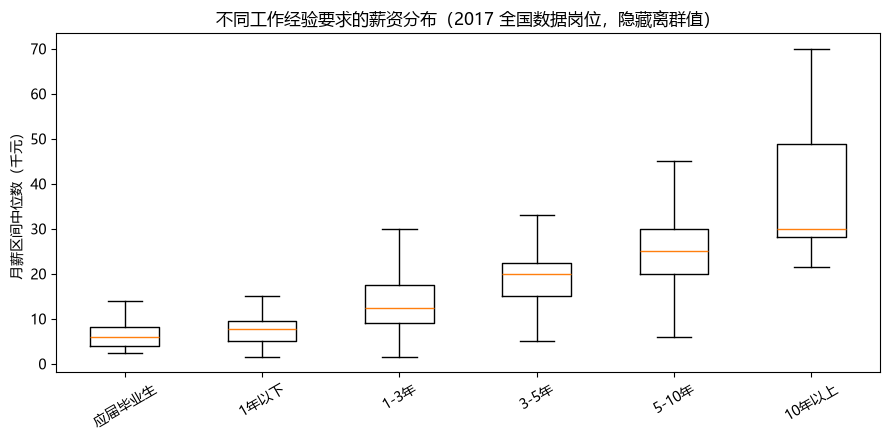

In [5]:
def 解析薪资(文本):
    """把 '7k-9k' 这类区间薪资解析为中位数（千元/月）；无法解析返回 None。"""
    if pd.isna(文本):
        return None
    nums = re.findall(r"(\d+(?:\.\d+)?)\s*[kK]", str(文本))
    if len(nums) >= 2:
        return (float(nums[0]) + float(nums[1])) / 2
    if len(nums) == 1:
        return float(nums[0])
    return None

pos["薪资中位k"] = pos["salary"].map(解析薪资)
hz["薪资中位k"] = hz["salary"].map(解析薪资)
print("position_sql 可解析比例:", round(pos["薪资中位k"].notna().mean(), 3))
print("lagou_hz_2  可解析比例:", round(hz["薪资中位k"].notna().mean(), 3))

fig, ax = plt.subplots(figsize=(9, 4.5))
数据 = [pos.loc[pos["workYear"] == g, "薪资中位k"].dropna() for g in 经验顺序[:-1]]
ax.boxplot(数据, tick_labels=经验顺序[:-1], showfliers=False)
ax.set_title("不同工作经验要求的薪资分布（2017 全国数据岗位，隐藏离群值）")
ax.set_ylabel("月薪区间中位数（千元）")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG / "02_薪资与经验.png", dpi=150)
plt.show()

## 5. 文本字段初探与 AI 关键词预演

杭州站表包含完整职位描述（`job_desc`），是后续技能词频分析的核心文本字段。这里先看一下文本长度分布，并用一个简易关键词清单做一次「AI 技能词频」的预演（正式的技能词典将在第二阶段构建）。

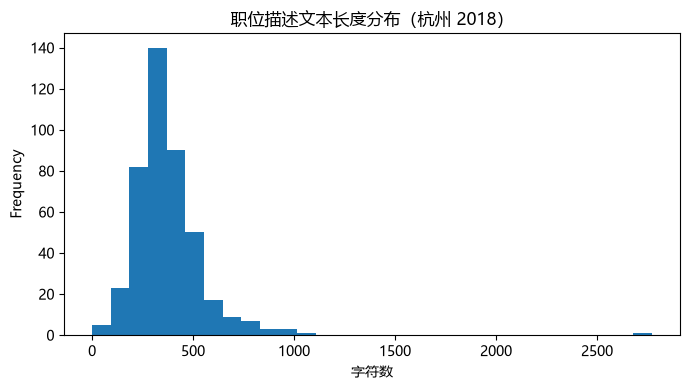

SQL           252
Python        178
Hadoop        127
Spark         108
Excel          91
机器学习           63
人工智能           16
深度学习            9
自然语言处理          8
神经网络            7
TensorFlow      3
PyTorch         0
dtype: int64


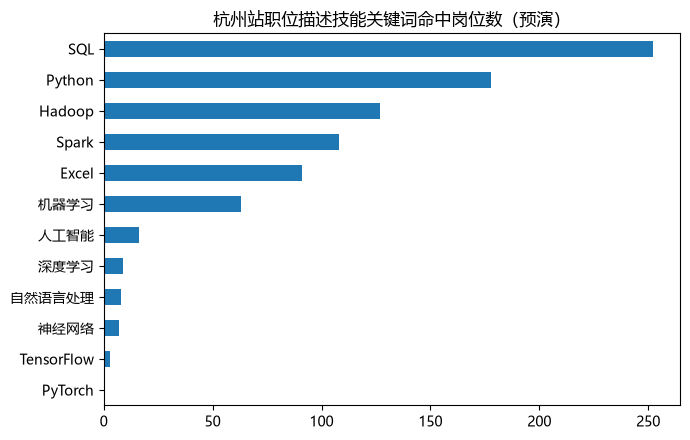

In [6]:
hz["描述长度"] = hz["job_desc"].fillna("").str.len()
fig, ax = plt.subplots(figsize=(7, 4))
hz["描述长度"].plot.hist(bins=30, ax=ax, title="职位描述文本长度分布（杭州 2018）")
ax.set_xlabel("字符数")
plt.tight_layout()
plt.savefig(FIG / "03_职位描述长度.png", dpi=150)
plt.show()

# 预演：统计若干技能关键词在职位描述中的命中岗位数
关键词 = ["机器学习", "深度学习", "人工智能", "神经网络", "自然语言处理",
          "TensorFlow", "PyTorch", "Python", "Hadoop", "Spark", "SQL", "Excel"]
文本 = hz["job_desc"].fillna("")
命中 = pd.Series({kw: int(文本.str.contains(kw, case=False, regex=False).sum()) for kw in 关键词})
print(命中.sort_values(ascending=False))
命中.sort_values().plot.barh(figsize=(7, 4.5), title="杭州站职位描述技能关键词命中岗位数（预演）")
plt.tight_layout()
plt.savefig(FIG / "04_技能关键词预演.png", dpi=150)
plt.show()

In [7]:
# 把解析后的日期与薪资写回 data/processed/，供后续阶段直接使用
PROC = Path("../data/processed")
PROC.mkdir(exist_ok=True)
pos.to_csv(PROC / "position_2017_薪资解析.csv", index=False)
hz.drop(columns=["描述长度"]).to_csv(PROC / "lagou_hz_2018_日期薪资解析.csv", index=False)
print("已写入:", [p.name for p in PROC.glob("*.csv")])

已写入: ['lagou_hz_2018_日期薪资解析.csv', 'position_2017_薪资解析.csv']


## 6. 小结：发现与局限

**发现**
1. 三张表整体质量较好：核心字段（职位名称、学历、经验、薪资）缺失率极低；缺失主要集中在公司标签、商圈等次要字段。
2. 岗位以「3-5 年」「1-3 年」经验档位为主（合计约 70%），应届毕业生岗位仅 135 个（2.7%），做初级/高级对比时需注意样本不均衡。
3. 薪资区间文本几乎全部可解析为数值，且随经验档位单调上升，支持用它作为岗位层级的辅助校验。
4. 杭州站数据的 `job_desc` 为完整长文本，关键词预演显示 SQL、Excel、Python 出现频率远高于深度学习/TensorFlow 等 AI 词——2018 年的数据岗位仍以传统分析技能为主。

**局限（直接影响研究设计，详见 `docs/research_design.md`）**
1. **时间跨度不足**：两个快照（2017 年中、2018 年 5 月）都早于本轮生成式 AI 浪潮（2022 年底起），无法单独回答研究问题 1 的「随时间变化」；本阶段数据定位为**流程跑通的试点数据**，正式分析需补充 2020 年后的公开数据集（候选见 `docs/data_acquisition_plan.md`）。
2. 2017 年全国表缺少职位描述全文，只有技能标签（`positionLables`），文本挖掘深度受限。
3. 两份数据来源口径不同（全国多类数据岗位 vs 杭州单城市数据分析岗），不能直接拼接比较。